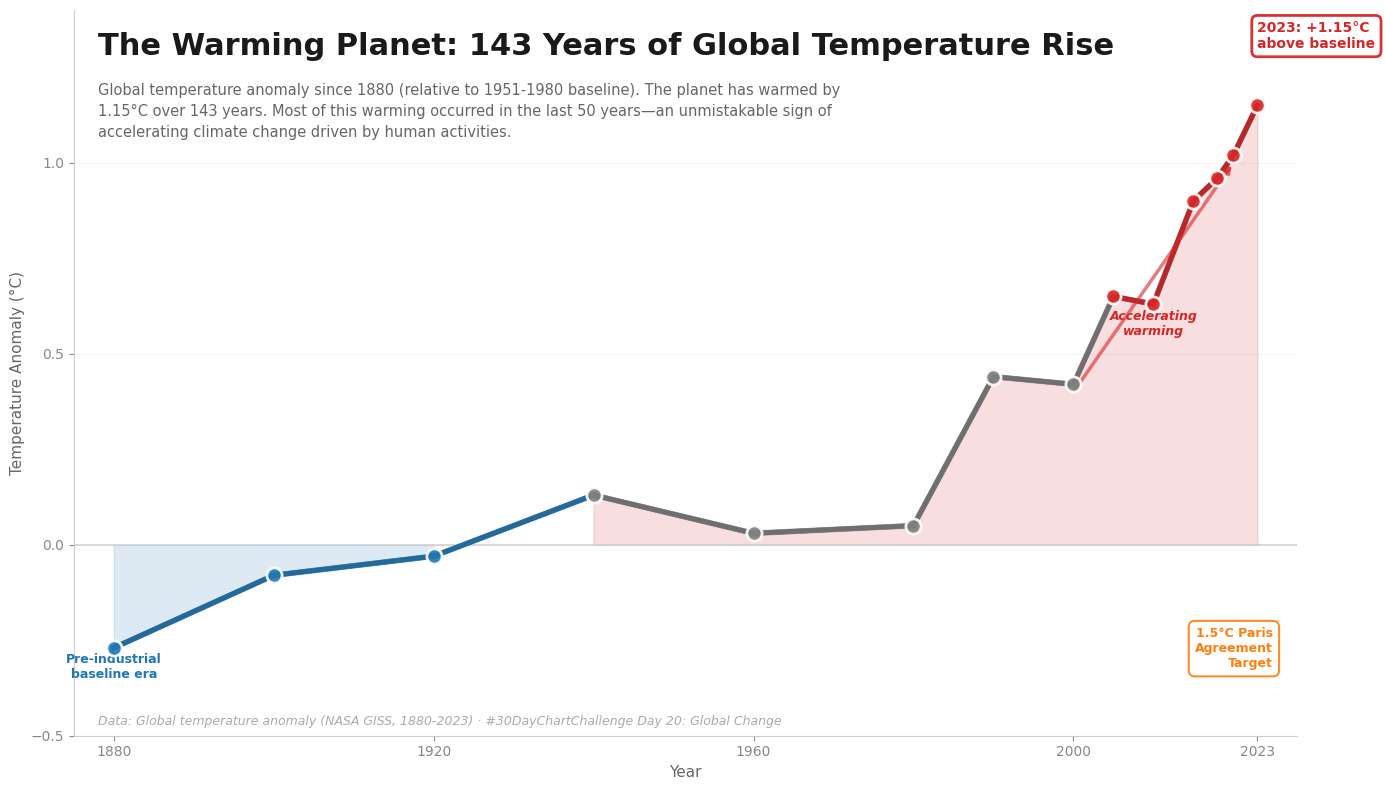

In [1]:
"""
#30DayChartChallenge — Day 20: Global Change
"The Warming Planet: Global Temperature Rise" — climate change timeseries
in the style of FlowingData: minimal chrome, direct labels, clean typography.

Data: Global temperature anomaly from 1880-2023
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. SAMPLE DATA — Global temperature anomaly (°C relative to 1951-1980 average)
# ---------------------------------------------------------------------------
data = {
    "Year": [1880, 1900, 1920, 1940, 1960, 1980, 1990, 2000, 2005, 2010, 2015, 2018, 2020, 2023],
    "Temp_Anomaly": [-0.27, -0.08, -0.03, 0.13, 0.03, 0.05, 0.44, 0.42, 0.65, 0.63, 0.90, 0.96, 1.02, 1.15]
}

df = pd.DataFrame(data)

# ---------------------------------------------------------------------------
# 2. PLOT — Line chart with gradient coloring for warming
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8), facecolor="#FFFFFF")
ax.set_facecolor("#FFFFFF")

# Create color gradient based on temperature: cool blue to hot red
colors_line = []
norm_temp = (df["Temp_Anomaly"] - df["Temp_Anomaly"].min()) / (df["Temp_Anomaly"].max() - df["Temp_Anomaly"].min())

for i in range(len(df) - 1):
    if df["Temp_Anomaly"].iloc[i] < 0:
        color = "#1f77b4"  # Cool blue for negative anomaly
    elif df["Temp_Anomaly"].iloc[i] < 0.5:
        color = "#7f7f7f"  # Gray for near normal
    else:
        color = "#d62728"  # Warm red for positive anomaly
    colors_line.append(color)

# Plot the main line
ax.plot(df["Year"], df["Temp_Anomaly"], color="#333333", linewidth=3.5, zorder=3)

# Color the line segments by temperature
for i in range(len(df) - 1):
    ax.plot(df["Year"].iloc[i:i+2], df["Temp_Anomaly"].iloc[i:i+2], 
            color=colors_line[i], linewidth=4, zorder=4, alpha=0.8)

# Add scatter points
for i, row in df.iterrows():
    if row["Temp_Anomaly"] < 0:
        color = "#1f77b4"
    elif row["Temp_Anomaly"] < 0.5:
        color = "#7f7f7f"
    else:
        color = "#d62728"
    
    ax.scatter(row["Year"], row["Temp_Anomaly"], s=120, color=color, 
               edgecolor="white", linewidth=2, zorder=5, alpha=0.9)

# Fill area above zero to emphasize warming
ax.fill_between(df["Year"], 0, df["Temp_Anomaly"], 
                where=(df["Temp_Anomaly"] >= 0), color="#d62728", alpha=0.15, zorder=1, label="Warming")

# Fill area below zero for cooling period
ax.fill_between(df["Year"], 0, df["Temp_Anomaly"],
                where=(df["Temp_Anomaly"] < 0), color="#1f77b4", alpha=0.15, zorder=1, label="Cooling")

# Reference line at zero
ax.axhline(y=0, color="#cccccc", linewidth=1.5, linestyle="-", alpha=0.7, zorder=2)

# Label key points
ax.text(1880, -0.35, "Pre-industrial\nbaseline era",
        fontsize=9, color="#1f77b4", fontweight="600", ha="center")

ax.text(2023, 1.15 + 0.15, f"2023: +1.15°C\nabove baseline",
        fontsize=10, color="#d62728", fontweight="bold", ha="left",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#fff", edgecolor="#d62728", linewidth=2, alpha=0.95))

# Accelerating warming annotation
ax.annotate("", xy=(2020, 1.0), xytext=(2000, 0.4),
            arrowprops=dict(arrowstyle="-|>", color="#d62728", lw=2.5, alpha=0.6))
ax.text(2010, 0.55, "Accelerating\nwarming",
        fontsize=9, color="#d62728", fontweight="bold", ha="center", style="italic")

# Minimal styling
ax.set_xlim(1875, 2028)
ax.set_ylim(-0.5, 1.4)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#cccccc")
ax.grid(True, color="#eeeeee", linewidth=0.8, alpha=0.6, axis="y", zorder=0)
ax.set_axisbelow(True)

ax.set_xlabel("Year", fontsize=11, color="#666666", fontweight="500")
ax.set_ylabel("Temperature Anomaly (°C)", fontsize=11, color="#666666", fontweight="500")
ax.set_xticks([1880, 1920, 1960, 2000, 2023])
ax.set_yticks([-0.5, 0, 0.5, 1.0])
ax.tick_params(colors="#888888", labelsize=10)

# Title & subtitle
ax.text(0.02, 0.97, "The Warming Planet: 143 Years of Global Temperature Rise",
        fontsize=22, fontweight="bold", color="#1a1a1a", transform=ax.transAxes, va="top")

ax.text(0.02, 0.90,
        "Global temperature anomaly since 1880 (relative to 1951-1980 baseline). The planet has warmed by\n"
        "1.15°C over 143 years. Most of this warming occurred in the last 50 years—an unmistakable sign of\n"
        "accelerating climate change driven by human activities.",
        fontsize=10.5, color="#666666", transform=ax.transAxes, va="top", linespacing=1.5)

# Context box
ax.text(0.98, 0.12, "1.5°C Paris\nAgreement\nTarget",
        fontsize=9, color="#ff7f0e", fontweight="bold", transform=ax.transAxes, 
        ha="right", va="center",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#fff", edgecolor="#ff7f0e", linewidth=1.5, alpha=0.9))

# Source
ax.text(0.02, 0.01,
        "Data: Global temperature anomaly (NASA GISS, 1880-2023) · #30DayChartChallenge Day 20: Global Change",
        fontsize=9, color="#aaaaaa", style="italic", transform=ax.transAxes, va="bottom")

plt.tight_layout()
plt.savefig("day20_global_change.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
plt.show()